<a href="https://colab.research.google.com/github/Chathuranga630/sionna/blob/main/Resilience_Paper.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# SIONNA 2.1 INSTALLATION FOR GOOGLE COLAB
# ============================================================

!pip install -q --upgrade pip

# Sionna 2.1 / Numba-compatible NumPy
!pip install -q --force-reinstall "numpy==2.2.6"

# Sionna 2.1
!pip install -q "sionna==2.1.0"

print("Installation finished.")
print("NOW RESTART THE RUNTIME:")
print("Runtime -> Restart session")

Installation finished.
NOW RESTART THE RUNTIME:
Runtime -> Restart session


In [1]:
import numpy as np

print("NumPy version:", np.__version__)

import numba

print("Numba version:", numba.__version__)

import sionna.phy

print("Sionna PHY imported successfully")
print("Sionna version:", getattr(sionna.phy, "__version__", "2.x"))

NumPy version: 2.2.6
Numba version: 0.61.2
Sionna PHY imported successfully
Sionna version: 2.x


In [2]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

import sionna.phy
from sionna.phy.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver
from sionna.phy.channel import AWGN, OFDMChannel
from sionna.phy.channel.tr38901 import AntennaArray, UMi
from sionna.phy.utils import compute_ber, ebnodb2no

print("NumPy :", np.__version__)
print("PyTorch:", torch.__version__)
print("Sionna imported successfully")

NumPy : 2.2.6
PyTorch: 2.11.0+cu128
Sionna imported successfully


In [13]:
# ---------------- Simulation assumptions ----------------
N_USERS = 4
PRB = 4
EBNO_DB = np.arange(-2, 16, 2)

# Service/QoS assumptions (replace for your target service)
TARGET_RATE_MBPS = np.array([20., 10., 5., 5.])  # priority-weighted service targets
PRIORITY = np.array([1.0, 0.8, 0.5, 0.5])
Q_THRESHOLD = 0.80
ETH = 0.75                     # normalized QoS-deviation threshold (assumption)
T_NMIN_MS = 10.0               # I1 threshold (assumption)
DMIN_MS = 8.0                   # I2 threshold (assumption)
TPROC_MS = 7.0                 # I4 threshold (assumption)
TSLEEP_MAX_MS = 20.0            # I5 threshold (assumption)

# Prompt/control timing assumptions
TGEN_MS = np.array([1.5,1.7,1.6,1.8,1.9,2.0,2.1,2.0,2.2,2.3])
D_MS = np.array([0.8,0.9,1.0,1.1,1.2,1.4,1.3,1.5,1.6,1.8])
C_MS = 0.5

# RIS timing assumptions; physical channel effect is applied later as a gain parameter
T_RIS_IT_MS = np.array([0.6,0.7,0.5,0.8,0.9,0.7,0.8,1.0,0.9,1.1])
RIS_GAIN_DB = 3.0

In [39]:
# A compact PUSCH configuration
from sionna.phy.nr import TBConfig

tb_config = TBConfig() # Initialize TBConfig without arguments
tb_config.modulation = "qpsk" # Assign modulation as string
pusch_config = PUSCHConfig(tb_config=tb_config)
pusch_config.n_size_bwp = PRB
pusch_config.num_antenna_ports = 1
pusch_config.num_layers = 1
pusch_config.dmrs.dmrs_port_set = [0]

tx = PUSCHTransmitter(pusch_config)
rx = PUSCHReceiver(tx)

# For a fast Colab run, use AWGN first. Replace with the UMi block below
# when you want a 3GPP spatial channel.
channel_awgn = AWGN()

# Dictionary to map modulation string to num_bits_per_symbol
modulation_bits_map = {
    "bpsk": 1,
    "qpsk": 2,
    "16qam": 4,
    "64qam": 6,
    "256qam": 8,
    "1024qam": 10
}

# Define coderate explicitly, as TBConfig.target_coderate is not directly settable
coderate_value = 0.5

def run_awgn_ber(ebno_db_values, batch_size=32):
    ber = []
    for ebno in ebno_db_values:
        # The exact no conversion depends on the configured waveform;
        # this is a compact link-level example for the resilience workflow.
        x, b = tx(batch_size)

        mod_string = pusch_config.tb.modulation # Access the modulation string
        if isinstance(mod_string, str):
            num_bits_per_symbol = modulation_bits_map.get(mod_string.lower(), None)
            if num_bits_per_symbol is None:
                raise ValueError(f"Unsupported modulation string: {mod_string}")
        else:
            # Fallback for if it eventually becomes a Modulation object
            num_bits_per_symbol = pusch_config.tb.modulation.num_bits_per_symbol

        # Use the explicitly defined coderate_value
        no = ebnodb2no(ebno, num_bits_per_symbol, coderate_value)
        y = channel_awgn(x, no)
        b_hat = rx(y, no)
        ber.append(float(compute_ber(b, b_hat).cpu().numpy())) # Added .cpu() here
    return np.array(ber)

ber = run_awgn_ber(EBNO_DB)
pd.DataFrame({"Eb/N0_dB":EBNO_DB, "BER":ber})

,Eb/N0_dB,BER
0,-2,0.328125
1,0,0.290033
2,2,0.243251
3,4,0.198456
4,6,0.144416
5,8,0.001687
6,10,0.000000
7,12,0.000000
8,14,0.000000


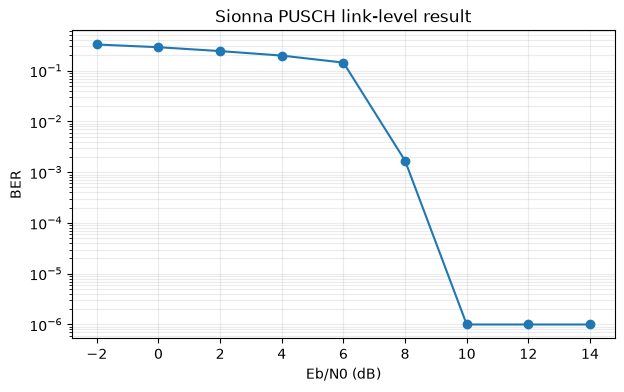

In [40]:
# Plot the physical-layer output
plt.figure(figsize=(7,4))
plt.semilogy(EBNO_DB, np.maximum(ber,1e-6), marker="o")
plt.xlabel("Eb/N0 (dB)")
plt.ylabel("BER")
plt.title("Sionna PUSCH link-level result")
plt.grid(True, which="both", alpha=.25)
plt.show()

In [41]:
# A deterministic service event model that consumes the physical-layer quality.
# Replace the illustrative BLER mapping with Sionna BLER measurements from a
# longer run when generating publication figures.

def bler_proxy(ebno):
    # Smooth proxy used only to demonstrate the service-layer pipeline.
    return 1/(1+np.exp(1.25*(ebno-6.0)))

base_bler = bler_proxy(EBNO_DB)
base_goodput = 1-base_bler

# Incident: 6 dB equivalent degradation, followed by recovery
timeline = np.arange(0, 20.1, 0.1)
ebno_t = np.full_like(timeline, 10.0)
ebno_t[(timeline>=5)&(timeline<8)] -= 6.0
for start, end in [(8,11)]:
    mask=(timeline>=start)&(timeline<end)
    ebno_t[mask] = 4.0 + (timeline[mask]-start)/(end-start)*6.0

goodput_t = 1-bler_proxy(ebno_t)
Q0 = np.sum(PRIORITY*TARGET_RATE_MBPS)
Q_t = goodput_t * Q0
q_t = Q_t/Q0

Dmax = 1-q_t.min()
tf = timeline[np.where(q_t < Q_THRESHOLD)[0][0]]
tr = timeline[np.where((timeline > 8) & (q_t >= Q_THRESHOLD))[0][0]]
T_recovery = tr-tf

print("Dmax =", round(float(Dmax),3))
print("T_recovery =", round(float(T_recovery),2), "time units")

Dmax = 0.924
T_recovery = 4.6 time units


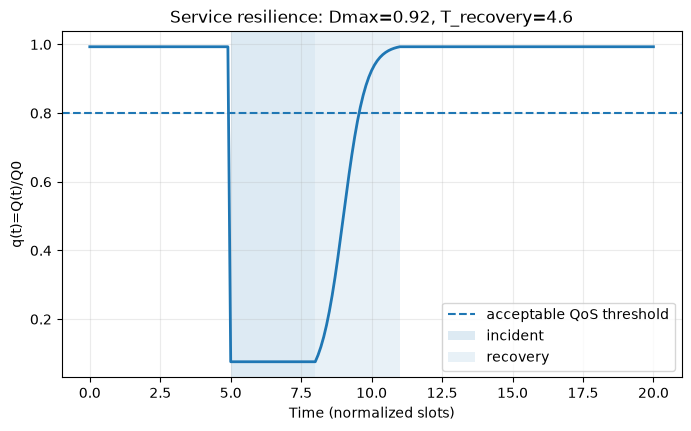

In [42]:
plt.figure(figsize=(8,4.5))
plt.plot(timeline,q_t,linewidth=2)
plt.axhline(Q_THRESHOLD,linestyle="--",label="acceptable QoS threshold")
plt.axvspan(5,8,alpha=.15,label="incident")
plt.axvspan(8,11,alpha=.10,label="recovery")
plt.xlabel("Time (normalized slots)")
plt.ylabel("q(t)=Q(t)/Q0")
plt.title(f"Service resilience: Dmax={Dmax:.2f}, T_recovery={T_recovery:.1f}")
plt.grid(True,alpha=.25); plt.legend()
plt.show()

Tresp = 17.599999999999998 ms
Talloc = 36.699999999999996 ms
I1 triggered: True
sum(d_i) = 12.6 ms
I2 triggered: True


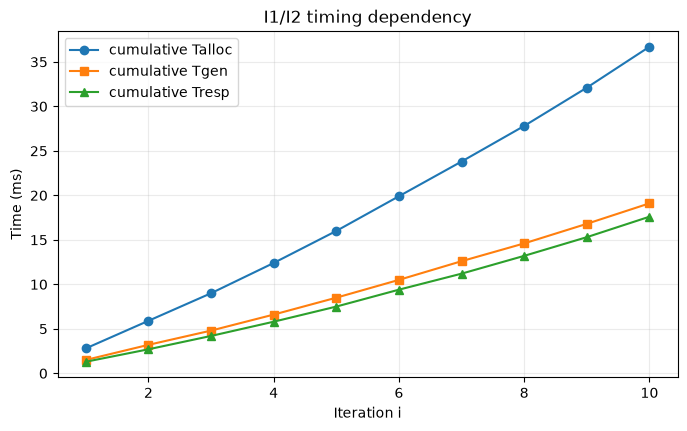

In [43]:
tresp = D_MS + C_MS
Talloc_i = TGEN_MS + tresp
Tresp_total = np.sum(tresp)

I1 = Tresp_total > T_NMIN_MS
I2 = np.sum(D_MS) > DMIN_MS

print("Tresp =", Tresp_total, "ms")
print("Talloc =", np.sum(Talloc_i), "ms")
print("I1 triggered:", I1)
print("sum(d_i) =", np.sum(D_MS), "ms")
print("I2 triggered:", I2)

plt.figure(figsize=(8,4.5))
plt.plot(np.arange(1,len(Talloc_i)+1), np.cumsum(Talloc_i), marker="o", label="cumulative Talloc")
plt.plot(np.arange(1,len(TGEN_MS)+1), np.cumsum(TGEN_MS), marker="s", label="cumulative Tgen")
plt.plot(np.arange(1,len(tresp)+1), np.cumsum(tresp), marker="^", label="cumulative Tresp")
plt.xlabel("Iteration i"); plt.ylabel("Time (ms)")
plt.title("I1/I2 timing dependency")
plt.grid(True,alpha=.25); plt.legend()
plt.show()

e_delta_Q (MSE) = 0.941
I3 triggered = True


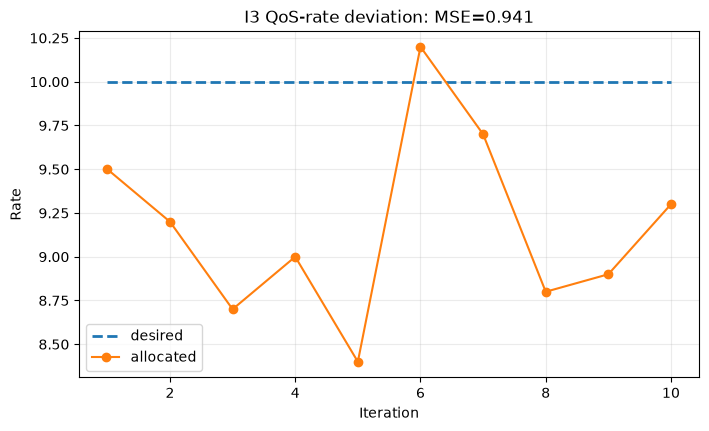

In [44]:
desired = np.repeat(TARGET_RATE_MBPS.mean(), len(TGEN_MS))
allocated = desired * np.array([.95,.92,.87,.90,.84,1.02,.97,.88,.89,.93])
e_delta_Q = np.mean((allocated-desired)**2)
I3 = e_delta_Q > ETH

print("e_delta_Q (MSE) =", round(float(e_delta_Q),4))
print("I3 triggered =", I3)

plt.figure(figsize=(8,4.5))
plt.plot(np.arange(1,len(desired)+1),desired,linestyle="--",linewidth=2,label="desired")
plt.plot(np.arange(1,len(allocated)+1),allocated,marker="o",label="allocated")
plt.xlabel("Iteration"); plt.ylabel("Rate")
plt.title(f"I3 QoS-rate deviation: MSE={e_delta_Q:.3f}")
plt.grid(True,alpha=.25); plt.legend()
plt.show()

TRIS = 8.0 ms
Emax (configured gain proxy) = 3.0 dB
I4 triggered = True
Tsleep = 12.0 ms
I5 triggered = True


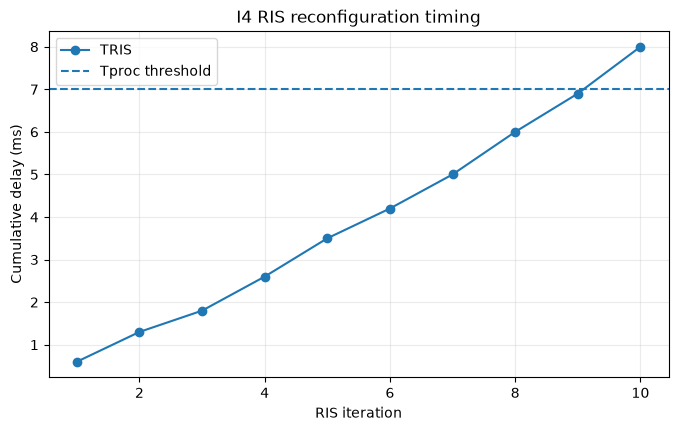

In [46]:
TRIS = np.sum(T_RIS_IT_MS)
Emax = RIS_GAIN_DB
I4 = TRIS > TPROC_MS

# Example observed sleep duration; replace with controller logs
Tsleep = 12.0
I5 = Tsleep < TSLEEP_MAX_MS

print("TRIS =", TRIS, "ms")
print("Emax (configured gain proxy) =", Emax, "dB")
print("I4 triggered =", I4)
print("Tsleep =", Tsleep, "ms")
print("I5 triggered =", I5)

plt.figure(figsize=(8,4.5))
plt.plot(np.arange(1,len(T_RIS_IT_MS)+1),np.cumsum(T_RIS_IT_MS),marker="o",label="TRIS")
plt.axhline(TPROC_MS,linestyle="--",label="Tproc threshold")
plt.xlabel("RIS iteration"); plt.ylabel("Cumulative delay (ms)")
plt.title("I4 RIS reconfiguration timing")
plt.grid(True,alpha=.25); plt.legend()
plt.show()